Genomic DNA Sequencing and DNA Editing Efficiency Calculations

In [24]:
import re
from itertools import groupby
from Bio import pairwise2
from Bio.Seq import Seq
import matplotlib.pyplot as plt
import numpy as np
from Bio.Seq import Seq
import numpy as np

In [25]:
def parse_fastq(fastq_file):
    with open(fastq_file, 'r') as file:
        while True:
            header = file.readline().strip()
            if not header:
                break
            sequence = file.readline().strip()
            _ = file.readline().strip()
            quality = file.readline().strip()
            yield header, sequence, quality

def one_point_mutation(primer):
    nucleotides = ["A", "T", "G", "C"]
    for index, base in enumerate(primer):
        for nt in nucleotides:
            if base != nt:
                yield primer[:index] + nt + primer[index+1:]

def extract_subsequence_with_extra_bases(sequence, target_seq, preceding_bases, following_bases):
    mutated_target_seqs = list(one_point_mutation(target_seq))
    all_target_seqs = [target_seq] + mutated_target_seqs
    for target in all_target_seqs:
        match = re.search(target, sequence)
        if match:
            start = max(0, match.start() - preceding_bases)
            end = min(len(sequence), match.end() + following_bases)
            return sequence[start:end]
    return None

def extract_reads(fastq_file, forward_primer, target_seq, preceding_bases, following_bases):
    extracted_reads = []
    mutated_primers = list(one_point_mutation(forward_primer))
    
    for header, sequence, quality in parse_fastq(fastq_file):
        if re.search(forward_primer, sequence) or any(re.search(mut_primer, sequence) for mut_primer in mutated_primers):
            subseq = extract_subsequence_with_extra_bases(sequence, target_seq, preceding_bases, following_bases)
            if subseq:
                start_index = sequence.find(subseq)
                extracted_reads.append((header, subseq, quality[start_index:start_index+len(subseq)]))
    
    return extracted_reads

V4

In [26]:
fastq_file = "C:/Users/madel/Downloads/SSSJS7_fastq/SSSJS7_1_BIN1V4Rep1.fastq"

# set forward and reverse primers
forward_primer_plasmid = "GGGCTTTGTCCCTGCTGTC"
reverse_primer_plasmid = "GCTGTGTCCTGTCCTGTGTCTG"
# set forward primer to plasmid primer
forward_primer = forward_primer_plasmid
reverse_primer = reverse_primer_plasmid

# set the spacer sequence
full_spacer = "GCCGCAGGTTGGGTCCCACC"
# match only the last 12 bases of the spacer sequence
# (anything before that might be edited)
# (might actually make more sense to match a sequence adjacent to the spacer)
target_seq_F = "GCCGCAGGTTGGGTCCCACC"
target_seq_R = "GGTGGGACCCAACCTGCGGC"

# extract reads and subsequences
# get forward reads
reads_r = extract_reads(fastq_file, reverse_primer, target_seq_R, preceding_bases=5, following_bases=0)
subsequences_r = [subseq for header, subseq, quality in reads_r]
subsequences_r = [str(Seq(sequence).reverse_complement()) for sequence in subsequences_r]
# get reverse reads
reads_f = extract_reads(fastq_file, forward_primer, target_seq_F, preceding_bases=0, following_bases=5)
subsequences_f = [subseq for header, subseq, quality in reads_f]
subsequences = subsequences_f + subsequences_r
subsequences = [str(Seq(seq).reverse_complement()) for seq in subsequences]


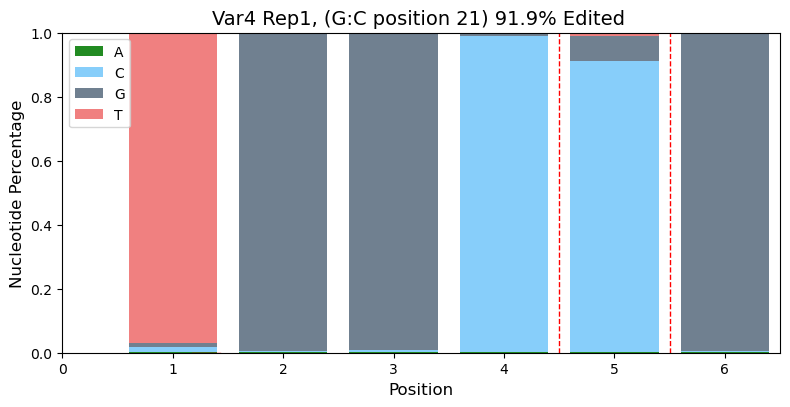

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plot_nucleotide_counts_with_edit_box(subsequences, edit_index):
    nucleotide_counts = {
        "A": [],
        "C": [],
        "G": [],
        "T": []
    }
    
    nucleotide_colors = {
        "A": "forestgreen",
        "C": "lightskyblue",
        "G": "slategray",
        "T": "lightcoral"
    }

    max_seq_length = max(len(subseq) for subseq in subsequences)
    
    # Count bases at edit index
    base_counts = {"A": 0, "C": 0, "G": 0, "T": 0}
    for subseq in subsequences:
        if edit_index < len(subseq):
            base_counts[subseq[edit_index]] += 1
    
    # Calculate editing percent
    cg_total = base_counts["C"] + base_counts["G"]
    editing_percent = (base_counts["C"] / cg_total * 100) if cg_total > 0 else 0

    for i in range(max_seq_length):
        position_counts = {"A": 0, "C": 0, "G": 0, "T": 0}
        for subseq in subsequences:
            if i < len(subseq):
                position_counts[subseq[i]] += 1
        total_counts = sum(position_counts.values())
        for nt in nucleotide_counts:
            nucleotide_counts[nt].append(position_counts[nt] / total_counts)
    
    x = np.arange(1, max_seq_length+1)
    y_offset = np.zeros(max_seq_length)
    
    plt.figure(figsize=(8, 4))
    for nt in nucleotide_counts:
        plt.bar(x, nucleotide_counts[nt], bottom=y_offset, label=nt, color=nucleotide_colors[nt])
        y_offset += nucleotide_counts[nt]
    
    # Highlight the edit position with a box
    plt.axvline(x=edit_index + 0.5, color='red', linestyle='--', linewidth=1)
    plt.axvline(x=edit_index + 1.5, color='red', linestyle='--', linewidth=1)
    plt.axhline(y=0, xmin=(edit_index + 0.5)/max_seq_length, xmax=(edit_index + 1.5)/max_seq_length, color='red', linewidth=1)
    plt.axhline(y=1.2, xmin=(edit_index + 0.5)/max_seq_length, xmax=(edit_index + 1.5)/max_seq_length, color='red', linewidth=1)
    
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel("Position", fontsize=12)
    plt.ylabel("Nucleotide Percentage", fontsize=12)
    plt.xlim(0, 6.5)
    plt.ylim(0, 1)
    plt.legend(loc="upper left", fontsize=10)
    plt.tight_layout()
    plt.title(f"Var4 Rep1, (G:C position 21) {editing_percent:.1f}% Edited ", fontsize=14)
    #plt.title("Var4, Control (No Editing) 2.6% variability ", fontsize=14)
    plt.savefig("Var4Rep1.pdf")
    plt.show()

    #for base, count in base_counts.items():
        #print(f"Number of sequences with base {base} at edit index: {count}")
        #print(f"Editing percent: {editing_percent:.2f}%")

edit_index = 4  # Edit index is 23rd position (indexing starts from 0)

plot_nucleotide_counts_with_edit_box(subsequences, edit_index)


V5

In [28]:
# Define your input FASTQ file
fastq_file = "C:/Users/madel/Downloads/SSSJS7_fastq/SSSJS7_3_BIN1V5Rep1.fastq"

# set forward and reverse primers
forward_primer_plasmid = "GGGCTTTGTCCCTGCTGTC"
reverse_primer_plasmid = "GCTGTGTCCTGTCCTGTGTCTG"
# set forward primer to plasmid primer
forward_primer = forward_primer_plasmid
reverse_primer = reverse_primer_plasmid

# set the spacer sequence
full_spacer = "GCTTTGTCCCTGCTGTCTTA"
# match only the last 12 bases of the spacer sequence
# (anything before that might be edited)
# (might actually make more sense to match a sequence adjacent to the spacer)
target_seq_F = "GCTTTGTCCCTGCTGTCTTA"
target_seq_R = "TAAGACAGCAGGGACAAAGC"

# extract reads and subsequences
# get forward reads
reads_r = extract_reads(fastq_file, reverse_primer, target_seq_R, preceding_bases=5, following_bases=0)
subsequences_r = [subseq for header, subseq, quality in reads_r]
subsequences_r = [str(Seq(sequence).reverse_complement()) for sequence in subsequences_r]
# get reverse reads
reads_f = extract_reads(fastq_file, forward_primer, target_seq_F, preceding_bases=0, following_bases=5)
subsequences_f = [subseq for header, subseq, quality in reads_f]
subsequences = subsequences_f + subsequences_r
subsequences = [str(Seq(seq).reverse_complement()) for seq in subsequences]


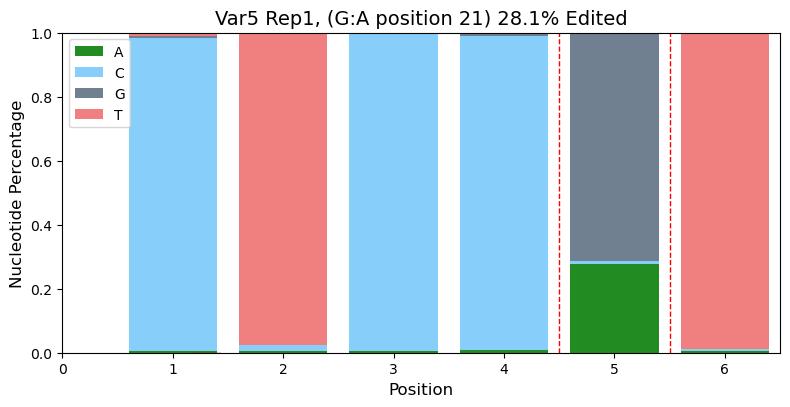

In [30]:
import matplotlib.pyplot as plt
import numpy as np

def plot_nucleotide_counts_with_edit_box(subsequences, edit_index):
    nucleotide_counts = {
        "A": [],
        "C": [],
        "G": [],
        "T": []
    }
    
    nucleotide_colors = {
        "A": "forestgreen",
        "C": "lightskyblue",
        "G": "slategray",
        "T": "lightcoral"
    }

    max_seq_length = max(len(subseq) for subseq in subsequences)
    
    base_counts = {"A": 0, "C": 0, "G": 0, "T": 0}
    for subseq in subsequences:
        if edit_index < len(subseq):
            base_counts[subseq[edit_index]] += 1
            
            # Calculate editing percent
    ag_total = base_counts["A"] + base_counts["G"]
    editing_percent = (base_counts["A"] / ag_total * 100) if ag_total > 0 else 0
    
    for i in range(max_seq_length):
        position_counts = {"A": 0, "C": 0, "G": 0, "T": 0}
        for subseq in subsequences:
            if i < len(subseq):
                position_counts[subseq[i]] += 1
        total_counts = sum(position_counts.values())
        for nt in nucleotide_counts:
            nucleotide_counts[nt].append(position_counts[nt] / total_counts)
    
    x = np.arange(1, max_seq_length+1)
    y_offset = np.zeros(max_seq_length)
    
    plt.figure(figsize=(8, 4))
    for nt in nucleotide_counts:
        plt.bar(x, nucleotide_counts[nt], bottom=y_offset, label=nt, color=nucleotide_colors[nt])
        y_offset += nucleotide_counts[nt]
    
    # Highlight the edit position with a box
    plt.axvline(x=edit_index + 0.5, color='red', linestyle='--', linewidth=1)
    plt.axvline(x=edit_index + 1.5, color='red', linestyle='--', linewidth=1)
    plt.axhline(y=0, xmin=(edit_index + 0.5)/max_seq_length, xmax=(edit_index + 1.5)/max_seq_length, color='red', linewidth=1)
    plt.axhline(y=1.2, xmin=(edit_index + 0.5)/max_seq_length, xmax=(edit_index + 1.5)/max_seq_length, color='red', linewidth=1)
    
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel("Position", fontsize=12)
    plt.ylabel("Nucleotide Percentage", fontsize=12)
    plt.xlim(0, 6.5)
    plt.ylim(0, 1)
    plt.legend(loc="upper left", fontsize=10)
    plt.tight_layout()
    plt.title(f"Var5 Rep1, (G:A position 21) {editing_percent:.1f}% Edited", fontsize=14)
    #plt.title("Var5, Control (No Editing) 0.06 % variability ", fontsize=14)
    plt.savefig("Var5Rep1.pdf")
    plt.show()

    #for base, count in base_counts.items():
        #print(f"Number of sequences with base {base} at edit index: {count}")


edit_index = 4  # Edit index is 23rd position (indexing starts from 0)

plot_nucleotide_counts_with_edit_box(subsequences, edit_index)

RNA Sequencing and PSI calculation

In [31]:
from Bio import SeqIO
from Bio import pairwise2

# Define file and sequences
fastq_file = "L8QX3T_2_BIN1V4RNARep2.fastq"
exon_included = "CACCACGACAGCAGGAAGAGAGCTGGAGGCTGCTTCACTTGCCGCCGTCTCCCCTGGCTCCTGGGCTCCAGCCGCAGGTTGGGTCCCACCCGCCACCTCCGAGGCCTCTGCTGGCTGAGATGGGGACTTGGGGAGGGTGGCCC"
exon_excluded = "CACCACGACAGCAGGAAGAGAGCTCTGAGATGGGGACTTGGGGAGGGTGGCCC"

# Allowable mismatches, insertions, and deletions
max_mismatches = 3

def match_with_tolerance(read, target, max_mismatches):
    alignments = pairwise2.align.localms(read, target, 2, -1, -2, -2)
    for alignment in alignments:
        seq1, seq2, score, start, end = alignment
        mismatches = sum(1 for a, b in zip(seq1[start:end], seq2[start:end]) if a != b)
        if mismatches <= max_mismatches:
            return True
    return False

# Count occurrences
included_count = 0
excluded_count = 0

# Read FASTQ file and check sequences
for record in SeqIO.parse(fastq_file, "fastq"):
    read_seq = str(record.seq)
    if match_with_tolerance(read_seq, exon_included, max_mismatches):
        included_count += 1
    elif match_with_tolerance(read_seq, exon_excluded, max_mismatches):
        excluded_count += 1

PSI=included_count/(included_count+excluded_count)
# Print results
print(PSI)

0.7298435619735258
